# SHAP Local Explanations & Clinical Benchmarking
## CVD Fairness Dissertation — NB2

Purpose: Examine why the model fails for specific female patients using local SHAP
explanations, matched comparisons, and a counterfactual test.

Loads precomputed SHAP arrays from outputs/shap/ — does not recompute them.

Does NOT contain: global summary plots, dependence plots, fairness metrics.
Those are in NB1 and fairness_evaluation.ipynb.

## 1. Imports

In [2]:
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from sklearn.preprocessing import StandardScaler

## 2. Paths and Constants

In [3]:
MODEL_PATH  = Path("../models/baseline_models/cardio_xgb_baseline_model.pkl")
TEST_DATA   = Path("../data/test_train_val_sets/cardio_baseline_test.csv")
CONFIG_PATH = Path("../config/dataset_split_sizes.json")
OUTPUT_SHAP = Path("../outputs/shap")

THRESHOLD  = 0.5
GENDER_COL = "gender"
FEMALE_VAL = 0
MALE_VAL   = 1
DROP_COLS  = ["cardio", "stratify"]

## 3. Sanity Checks

Checks that the model, test set, and precomputed SHAP arrays are all consistent
before any analysis runs.

In [4]:
with open(CONFIG_PATH) as f:
    expected_sizes = json.load(f)

test_df = pd.read_csv(TEST_DATA)
X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df["cardio"]

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

y_pred = model.predict(X_test)

# Check 1: test set size
assert len(test_df) == expected_sizes["test"], (
    f"Test size mismatch: got {len(test_df)}, expected {expected_sizes['test']}"
)

# Check 2: no target leakage
assert "cardio" not in X_test.columns, "cardio found in X_test"

# Check 3: no nulls
assert X_test.isnull().sum().sum() == 0, "Nulls found in X_test"

# Check 4: class balance
cvd_frac = test_df["cardio"].mean()
assert 0.48 < cvd_frac < 0.52, f"Unexpected class balance: {cvd_frac:.3f}"

# Check 5: sex distribution
female_frac = (test_df[GENDER_COL] == FEMALE_VAL).mean()
assert 0.62 < female_frac < 0.68, f"Unexpected female fraction: {female_frac:.3f}"

print("Test set checks passed")
print(f"  Size      : {len(test_df):,}")
print(f"  Female    : {female_frac:.3f}")
print(f"  CVD rate  : {cvd_frac:.3f}")

Test set checks passed
  Size      : 10,227
  Female    : 0.650
  CVD rate  : 0.495


In [5]:
# Load precomputed SHAP arrays saved by NB1
shap_full   = np.load(OUTPUT_SHAP / "shap_values_baseline_full.npy")
shap_female = np.load(OUTPUT_SHAP / "shap_values_baseline_female.npy")
shap_male   = np.load(OUTPUT_SHAP / "shap_values_baseline_male.npy")
base_value  = float(np.load(OUTPUT_SHAP / "shap_base_value.npy"))

# Check 6: SHAP array dimensions match test set
assert shap_full.shape == X_test.shape, (
    f"Full SHAP shape mismatch: {shap_full.shape} vs {X_test.shape}"
)

female_mask = test_df[GENDER_COL].values == FEMALE_VAL
male_mask   = test_df[GENDER_COL].values == MALE_VAL

X_test_female = X_test[female_mask].copy()
X_test_male   = X_test[male_mask].copy()
y_test_female = y_test.values[female_mask]
y_test_male   = y_test.values[male_mask]
y_pred_female = y_pred[female_mask]
y_pred_male   = y_pred[male_mask]

assert shap_female.shape == X_test_female.shape, (
    f"Female SHAP shape mismatch: {shap_female.shape} vs {X_test_female.shape}"
)
assert shap_male.shape == X_test_male.shape, (
    f"Male SHAP shape mismatch: {shap_male.shape} vs {X_test_male.shape}"
)

# Check 7: subgroup SHAP rows sum to full test set
assert shap_female.shape[0] + shap_male.shape[0] == len(X_test), (
    "Subgroup SHAP row counts do not sum to full test set"
)

print("SHAP array checks passed")
print(f"  Full SHAP   : {shap_full.shape}")
print(f"  Female SHAP : {shap_female.shape}")
print(f"  Male SHAP   : {shap_male.shape}")
print(f"  Base value  : {base_value:.4f}")

SHAP array checks passed
  Full SHAP   : (10227, 11)
  Female SHAP : (6649, 11)
  Male SHAP   : (3578, 11)
  Base value  : -0.0177


C:\Users\kavis\AppData\Local\Temp\ipykernel_19304\448354862.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_value  = float(np.load(OUTPUT_SHAP / "shap_base_value.npy"))


## 4. Build Prediction Groups

Defines false negative, true positive, and true negative masks for women and men.
These are used throughout the rest of the notebook.

In [7]:
fn_mask_f = (y_test_female == 1) & (y_pred_female == 0)
tp_mask_f = (y_test_female == 1) & (y_pred_female == 1)
tn_mask_f = (y_test_female == 0) & (y_pred_female == 0)

fn_mask_m = (y_test_male == 1) & (y_pred_male == 0)
tp_mask_m = (y_test_male == 1) & (y_pred_male == 1)
tn_mask_m = (y_test_male == 0) & (y_pred_male == 0)

fn_women = test_df[female_mask][fn_mask_f].copy()
tp_women = test_df[female_mask][tp_mask_f].copy()
tn_women = test_df[female_mask][tn_mask_f].copy()

fn_men = test_df[male_mask][fn_mask_m].copy()
tp_men = test_df[male_mask][tp_mask_m].copy()
tn_men = test_df[male_mask][tn_mask_m].copy()

# Check masks are mutually exclusive within each sex
assert not (fn_mask_f & tp_mask_f).any(), "FN and TP masks overlap for women"
assert not (fn_mask_m & tp_mask_m).any(), "FN and TP masks overlap for men"

print(f"Women  —  FN: {fn_mask_f.sum()}  TP: {tp_mask_f.sum()}  TN: {tn_mask_f.sum()}")
print(f"Men    —  FN: {fn_mask_m.sum()}  TP: {tp_mask_m.sum()}  TN: {tn_mask_m.sum()}")

Women  —  FN: 1007  TP: 2273  TN: 2617
Men    —  FN: 589  TP: 1198  TN: 1390


## 5. SHAP Comparison: FN vs TP Women

Compares mean SHAP values between false negative and true positive women.
Shows which features are driving the model toward predicting no CVD
for women it misses, compared to women it correctly identifies.

In [8]:
fn_shap = pd.DataFrame(shap_female[fn_mask_f], columns=X_test.columns)
tp_shap = pd.DataFrame(shap_female[tp_mask_f], columns=X_test.columns)

shap_compare = pd.DataFrame({
    "FN mean SHAP":  fn_shap.mean(),
    "TP mean SHAP":  tp_shap.mean(),
    "difference":    fn_shap.mean() - tp_shap.mean(),
    "FN abs SHAP":   fn_shap.abs().mean(),
    "TP abs SHAP":   tp_shap.abs().mean(),
}).sort_values("difference")

print("Mean SHAP comparison: FN women vs TP women")
print(shap_compare.round(4).to_string())

shap_compare.to_csv(OUTPUT_SHAP / "shap_fn_vs_tp_women_comparison.csv")

Mean SHAP comparison: FN women vs TP women
             FN mean SHAP  TP mean SHAP  difference  FN abs SHAP  TP abs SHAP
ap_hi             -0.6109        0.9095     -1.5205       0.6595       1.0420
cholesterol       -0.0822        0.1501     -0.2323       0.1805       0.2796
age_years         -0.0253        0.1350     -0.1603       0.2667       0.2130
ap_lo             -0.0498        0.0701     -0.1199       0.0610       0.0994
weight            -0.0249        0.0239     -0.0488       0.1119       0.0825
active            -0.0050        0.0043     -0.0093       0.0728       0.0557
height             0.0058        0.0115     -0.0058       0.0201       0.0256
gender             0.0075        0.0108     -0.0032       0.0076       0.0108
gluc               0.0088        0.0057      0.0031       0.0175       0.0462
alco               0.0082        0.0052      0.0031       0.0192       0.0167
smoke              0.0123        0.0082      0.0041       0.0167       0.0125


## 6. Mean SHAP Bar Chart — FN Women

Shows the average SHAP contribution of each feature for false negative women.
Red bars push the prediction toward no CVD, blue bars push toward CVD.
This shows which features are most responsible for the model missing these patients.

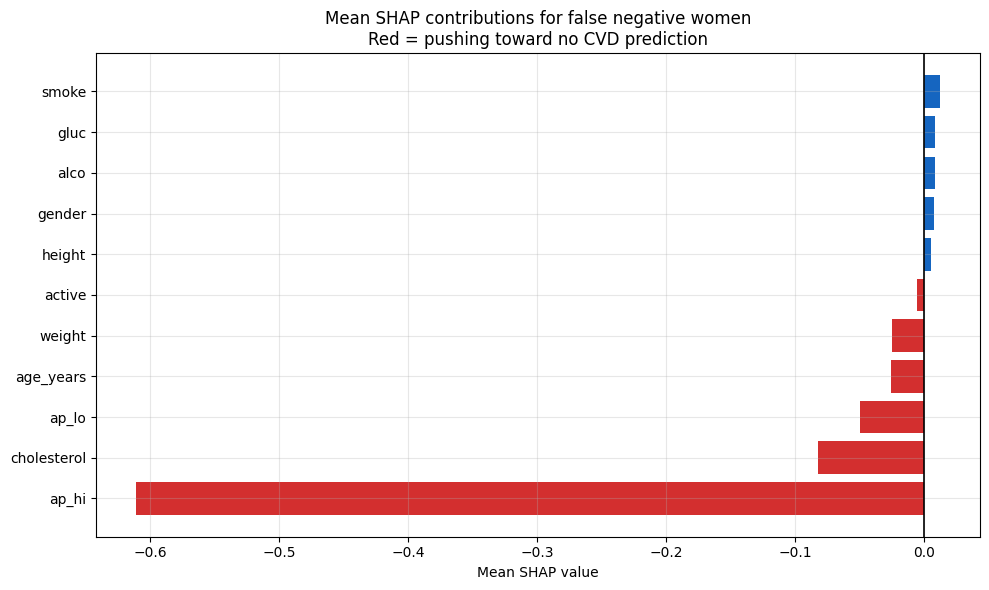

In [9]:
fn_mean_shap = fn_shap.mean().sort_values()
colors = ["#d32f2f" if v < 0 else "#1565c0" for v in fn_mean_shap.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fn_mean_shap.index, fn_mean_shap.values, color=colors)
ax.axvline(x=0, color="black", linewidth=1.2)
ax.set_xlabel("Mean SHAP value")
ax.set_title("Mean SHAP contributions for false negative women\nRed = pushing toward no CVD prediction")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_mean_bar_fn_women.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Most Common Negative SHAP Driver — FN Women

For each false negative woman, finds the feature with the largest negative
SHAP value (the feature pushing hardest toward no CVD).
Shows whether there is a consistent dominant driver across the group.

In [10]:
top_negative = fn_shap.idxmin(axis=1)
print("Most common dominant negative SHAP feature in false negative women:")
print(top_negative.value_counts().to_string())

def top_n_negative(row, n=2):
    return row.sort_values().head(n).index.tolist()

top2 = fn_shap.apply(top_n_negative, axis=1)
top2_df = pd.DataFrame(top2.tolist(), columns=["neg_1", "neg_2"])

print("\nTop 2 negative contributors, first 10 FN women:")
print(top2_df.head(10).to_string())

Most common dominant negative SHAP feature in false negative women:
ap_hi          896
cholesterol     52
age_years       44
weight          11
alco             3
ap_lo            1

Top 2 negative contributors, first 10 FN women:
         neg_1        neg_2
0        ap_hi  cholesterol
1        ap_hi  cholesterol
2        ap_hi  cholesterol
3        ap_hi  cholesterol
4        ap_hi    age_years
5  cholesterol        ap_lo
6        ap_hi       weight
7        ap_hi  cholesterol
8        ap_hi    age_years
9        ap_hi    age_years


## 8. SHAP Dependence: ap_hi — TP vs FN Women and Men

Shows where false negative women sit on the ap_hi SHAP dependence plot
compared to true positive women. The same plot is produced for men.

Clinical reference lines mark the female risk threshold (110 mmHg) and
male risk threshold (130 mmHg) from Ji et al.

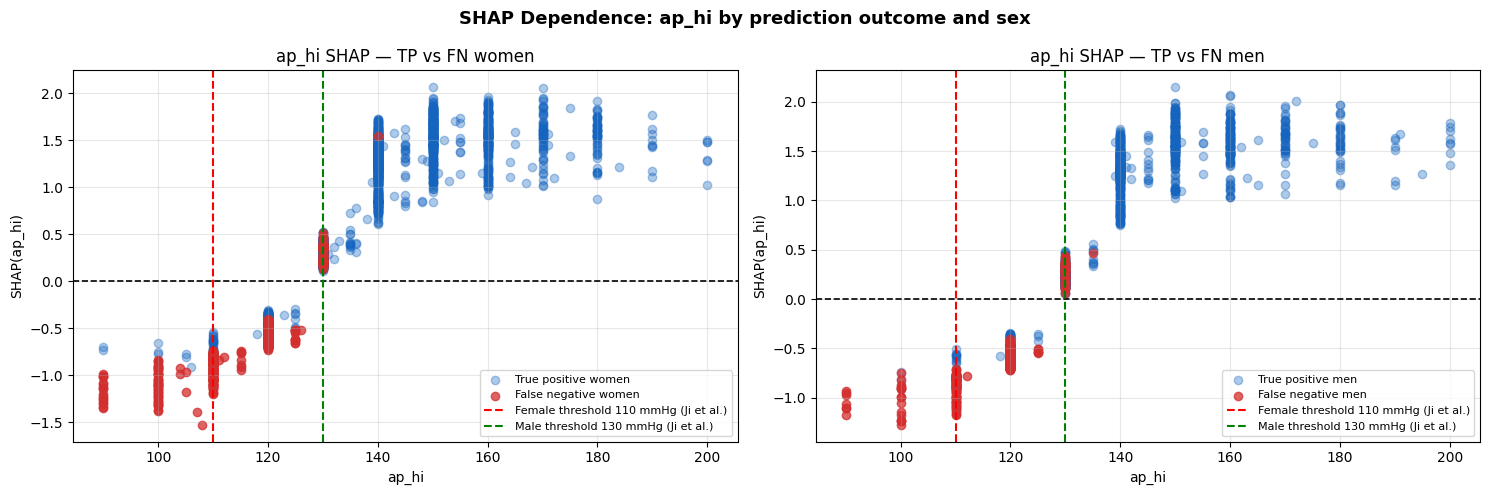

In [11]:
feat = "ap_hi"
feat_idx = list(X_test.columns).index(feat)

X_female_reset = X_test_female.reset_index(drop=True)
X_male_reset   = X_test_male.reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Women
axes[0].scatter(
    X_female_reset.loc[tp_mask_f, feat],
    shap_female[tp_mask_f, feat_idx],
    alpha=0.35, label="True positive women", color="#1565c0"
)
axes[0].scatter(
    X_female_reset.loc[fn_mask_f, feat],
    shap_female[fn_mask_f, feat_idx],
    alpha=0.75, label="False negative women", color="#d32f2f"
)
axes[0].axhline(y=0,   color="black", linestyle="--", linewidth=1.2)
axes[0].axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female threshold 110 mmHg (Ji et al.)")
axes[0].axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold 130 mmHg (Ji et al.)")
axes[0].set_xlabel("ap_hi")
axes[0].set_ylabel("SHAP(ap_hi)")
axes[0].set_title("ap_hi SHAP — TP vs FN women")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Men
axes[1].scatter(
    X_male_reset.loc[tp_mask_m, feat],
    shap_male[tp_mask_m, feat_idx],
    alpha=0.35, label="True positive men", color="#1565c0"
)
axes[1].scatter(
    X_male_reset.loc[fn_mask_m, feat],
    shap_male[fn_mask_m, feat_idx],
    alpha=0.75, label="False negative men", color="#d32f2f"
)
axes[1].axhline(y=0,   color="black", linestyle="--", linewidth=1.2)
axes[1].axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female threshold 110 mmHg (Ji et al.)")
axes[1].axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold 130 mmHg (Ji et al.)")
axes[1].set_xlabel("ap_hi")
axes[1].set_ylabel("SHAP(ap_hi)")
axes[1].set_title("ap_hi SHAP — TP vs FN men")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("SHAP Dependence: ap_hi by prediction outcome and sex", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_dependence_ap_hi_fn_vs_tp.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. SHAP Waterfall — FN Woman vs Nearest Matched Male

Selects the most representative false negative woman (closest to the median
FN profile) and finds the nearest male patient by clinical similarity.
Matching is done on age, systolic BP, cholesterol, and weight using
z-score normalised L2 distance.

The waterfall plots show exactly which features drove each prediction,
making it possible to compare the model's reasoning for two clinically
similar patients of different sex.

In [12]:
MATCHING_FEATURES = ["age_years", "ap_hi", "cholesterol", "weight"]

# Find most representative FN woman — closest to median FN profile
fn_std    = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median = fn_women[MATCHING_FEATURES].median()
distances = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1
)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# Find nearest male by z-score normalised L2 distance
males   = test_df[test_df[GENDER_COL] == MALE_VAL].copy()
males_X = X_test[male_mask].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("Feature comparison: FN woman vs matched male")
print(pd.DataFrame({
    "FN woman":     rep_woman[MATCHING_FEATURES].values,
    "matched male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

prob_woman = model.predict_proba(rep_woman_X.values.reshape(1, -1))[0, 1]
prob_male  = model.predict_proba(rep_male_X.values.reshape(1, -1))[0, 1]

print(f"\nFN woman predicted probability  : {prob_woman:.3f}")
print(f"Matched male predicted probability : {prob_male:.3f}")

Feature comparison: FN woman vs matched male
              FN woman matched male
age_years    53.686516    53.497604
ap_hi              120          120
cholesterol          1            1
weight            69.0         69.0

FN woman predicted probability  : 0.280
Matched male predicted probability : 0.277


c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
# Build single-row DataFrames for SHAP
explainer = shap.TreeExplainer(model)

woman_df = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df  = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)

sv_woman = explainer(woman_df)
sv_male  = explainer(male_df)

# Validation: counterfactual only changes gender column
woman_cf = woman_df.copy()
woman_cf[GENDER_COL] = MALE_VAL

all_same = (woman_df.drop(columns=GENDER_COL) == woman_cf.drop(columns=GENDER_COL)).all().all()
assert all_same, "Counterfactual changed more than just the gender column"
print("Counterfactual integrity check passed")

Counterfactual integrity check passed


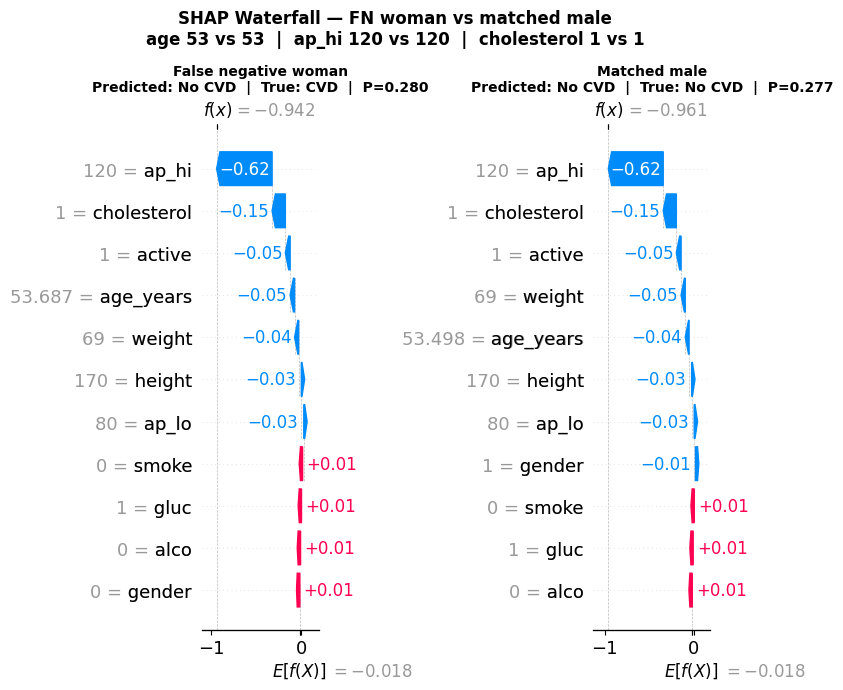


Top SHAP drivers sorted by absolute value (woman):
    feature  shap_woman  shap_male  diff (W-M)
      ap_hi   -0.615742  -0.616524    0.000783
cholesterol   -0.147494  -0.147447   -0.000047
     active   -0.052836  -0.053149    0.000313
  age_years   -0.049397  -0.042891   -0.006505
     weight   -0.044892  -0.046750    0.001857
     height   -0.030142  -0.029212   -0.000930
      ap_lo   -0.027448  -0.028780    0.001332
      smoke    0.013487   0.013504   -0.000017
       gluc    0.012104   0.012104    0.000000
       alco    0.010348   0.010343    0.000005


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(24, 9))

pred_woman = model.predict(woman_df.values)[0]
pred_male  = model.predict(male_df.values)[0]

plt.sca(axes[0])
shap.plots.waterfall(sv_woman[0], max_display=12, show=False)
axes[0].set_title(
    f"False negative woman\nPredicted: {'CVD' if pred_woman == 1 else 'No CVD'}  |  True: CVD  |  P={prob_woman:.3f}",
    fontsize=10, fontweight="bold"
)

plt.sca(axes[1])
shap.plots.waterfall(sv_male[0], max_display=12, show=False)
axes[1].set_title(
    f"Matched male\nPredicted: {'CVD' if pred_male == 1 else 'No CVD'}  |  True: {'CVD' if rep_male['cardio'] == 1 else 'No CVD'}  |  P={prob_male:.3f}",
    fontsize=10, fontweight="bold"
)

plt.suptitle(
    f"SHAP Waterfall — FN woman vs matched male\n"
    f"age {int(rep_woman['age_years'])} vs {int(rep_male['age_years'])}  |  "
    f"ap_hi {int(rep_woman['ap_hi'])} vs {int(rep_male['ap_hi'])}  |  "
    f"cholesterol {int(rep_woman['cholesterol'])} vs {int(rep_male['cholesterol'])}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_waterfall_fn_woman_vs_matched_male.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop SHAP drivers sorted by absolute value (woman):")
print(pd.DataFrame({
    "feature":   X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(index=False))

## 10. Counterfactual — Gender Swap

Takes the same false negative woman and changes only the gender column to male,
keeping every other feature identical. The change in predicted probability
shows the direct effect of the gender feature on the model's output.

In [17]:
sv_cf   = explainer(woman_cf)
prob_cf = model.predict_proba(woman_cf.values)[0, 1]
pred_cf = model.predict(woman_cf.values)[0]

print(f"Original (female) probability    : {prob_woman:.3f}  predicted: {'CVD' if pred_woman == 1 else 'No CVD'}")
print(f"Counterfactual (male) probability: {prob_cf:.3f}  predicted: {'CVD' if pred_cf == 1 else 'No CVD'}")
print(f"Probability difference (M - F)   : {prob_cf - prob_woman:+.3f}")

Original (female) probability    : 0.280  predicted: No CVD
Counterfactual (male) probability: 0.277  predicted: No CVD
Probability difference (M - F)   : -0.004


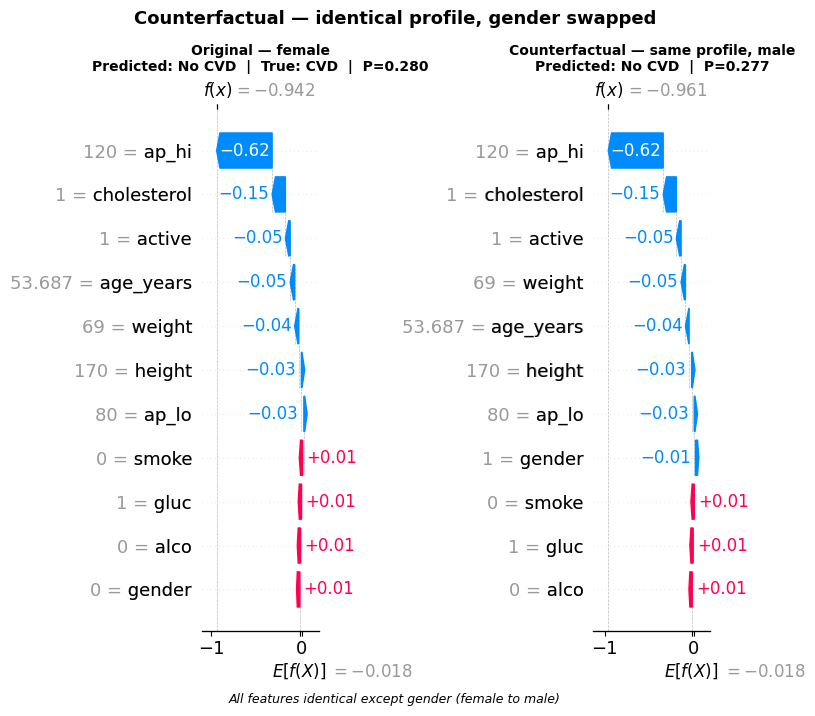

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(24, 9))

plt.sca(axes[0])
shap.plots.waterfall(sv_woman[0], max_display=12, show=False)
axes[0].set_title(
    f"Original — female\nPredicted: {'CVD' if pred_woman == 1 else 'No CVD'}  |  True: CVD  |  P={prob_woman:.3f}",
    fontsize=10, fontweight="bold"
)

plt.sca(axes[1])
shap.plots.waterfall(sv_cf[0], max_display=12, show=False)
axes[1].set_title(
    f"Counterfactual — same profile, male\nPredicted: {'CVD' if pred_cf == 1 else 'No CVD'}  |  P={prob_cf:.3f}",
    fontsize=10, fontweight="bold"
)

plt.suptitle("Counterfactual — identical profile, gender swapped", fontsize=13, fontweight="bold")
fig.text(0.5, -0.01, "All features identical except gender (female to male)",
         ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.savefig(OUTPUT_SHAP / "shap_counterfactual_gender_swap.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Clinical Benchmarking Summary

Compares the model's effective response threshold for ap_hi against the
sex-specific thresholds from Ji et al. Summarises where the false negative
women sit relative to both thresholds.

In [19]:
fn_women_bp = fn_women["ap_hi"]
tn_women_bp = tn_women["ap_hi"]

n_fn_below_130 = (fn_women_bp < 130).sum()
n_fn_110_130   = ((fn_women_bp >= 110) & (fn_women_bp < 130)).sum()
n_fn_total     = len(fn_women_bp)

print("False negative women — systolic BP distribution")
print(f"  Total FN women               : {n_fn_total}")
print(f"  BP below 130 mmHg            : {n_fn_below_130}  ({n_fn_below_130/n_fn_total*100:.1f}%)")
print(f"  BP in 110-129 mmHg range     : {n_fn_110_130}  ({n_fn_110_130/n_fn_total*100:.1f}%)")
print(f"  Mean BP                      : {fn_women_bp.mean():.1f} mmHg")
print(f"  Median BP                    : {fn_women_bp.median():.1f} mmHg")

print("\nClinical reference points (Ji et al.)")
print("  Female CVD risk threshold     : 110 mmHg")
print("  Male CVD risk threshold       : 130 mmHg")
print("  Model effective threshold     : ~130 mmHg (from SHAP dependence, NB1 section 9)")

print("\nInterpretation")
print("  The model applies the male-calibrated threshold to female patients.")
print("  Women with BP in the 110-129 range are clinically at risk but are")
print("  below the model's learned split point, explaining the elevated FN rate")
print("  in that bin (25.9%, from section 12 of NB1).")

False negative women — systolic BP distribution
  Total FN women               : 1007
  BP below 130 mmHg            : 928  (92.2%)
  BP in 110-129 mmHg range     : 855  (84.9%)
  Mean BP                      : 117.5 mmHg
  Median BP                    : 120.0 mmHg

Clinical reference points (Ji et al.)
  Female CVD risk threshold     : 110 mmHg
  Male CVD risk threshold       : 130 mmHg
  Model effective threshold     : ~130 mmHg (from SHAP dependence, NB1 section 9)

Interpretation
  The model applies the male-calibrated threshold to female patients.
  Women with BP in the 110-129 range are clinically at risk but are
  below the model's learned split point, explaining the elevated FN rate
  in that bin (25.9%, from section 12 of NB1).


In [20]:
# Save benchmarking summary as a table for the dissertation appendix
summary = pd.DataFrame([
    {"threshold": "Female clinical threshold (Ji et al.)", "ap_hi_mmhg": 110},
    {"threshold": "Male clinical threshold (Ji et al.)",   "ap_hi_mmhg": 130},
    {"threshold": "Model effective threshold (SHAP)",      "ap_hi_mmhg": 130},
    {"threshold": "FN women median BP",                    "ap_hi_mmhg": round(fn_women_bp.median(), 1)},
    {"threshold": "FN women mean BP",                      "ap_hi_mmhg": round(fn_women_bp.mean(), 1)},
])
summary.to_csv(OUTPUT_SHAP / "clinical_benchmarking_summary.csv", index=False)
print("Saved: clinical_benchmarking_summary.csv")

Saved: clinical_benchmarking_summary.csv


## 12. NB2 Output Summary

All outputs saved to outputs/shap/:

| File | Contents |
|---|---|
| shap_fn_vs_tp_women_comparison.csv | Mean SHAP per feature, FN vs TP women |
| shap_mean_bar_fn_women.png | Mean SHAP bar chart for FN women |
| shap_dependence_ap_hi_fn_vs_tp.png | ap_hi dependence, TP vs FN by sex |
| shap_waterfall_fn_woman_vs_matched_male.png | Waterfall comparison |
| shap_counterfactual_gender_swap.png | Counterfactual waterfall |
| clinical_benchmarking_summary.csv | Threshold comparison table |

Next: fairness_evaluation.ipynb